In [43]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
script_dir = os.getcwd()
project_root = os.path.dirname(script_dir)
df_path = os.path.join(project_root, "data", "processed", "Engineered_Telco_customer_churn.csv")

df = pd.read_csv(df_path)

In [45]:
df.head()

,Latitude,Longitude,Senior Citizen,Partner,Dependents,Tenure Months,Multiple Lines,Internet Service,Online Security,Online Backup,...,Payment Method,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV,Expected Monthly,Total Services,Security Score,Entertainment Score
0,33.964131,-118.272783,No,No,No,2,No,DSL,Yes,Yes,...,Mailed check,53.85,108.15,1,86,3239,54.075000,2,2,0
1,34.059281,-118.307420,No,No,Yes,2,No,Fiber optic,No,No,...,Electronic check,70.70,151.65,1,67,2701,75.825000,0,0,0
2,34.048013,-118.293953,No,No,Yes,8,Yes,Fiber optic,No,No,...,Electronic check,99.65,820.50,1,86,5372,102.562500,3,1,2
3,34.062125,-118.315709,No,Yes,Yes,28,Yes,Fiber optic,No,No,...,Electronic check,104.80,3046.05,1,84,5003,108.787500,4,2,2
4,34.039224,-118.266293,No,No,Yes,49,Yes,Fiber optic,No,Yes,...,Bank transfer (automatic),103.70,5036.30,1,89,5340,102.781633,4,2,2


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Latitude             7043 non-null   float64
 1   Longitude            7043 non-null   float64
 2   Senior Citizen       7043 non-null   object 
 3   Partner              7043 non-null   object 
 4   Dependents           7043 non-null   object 
 5   Tenure Months        7043 non-null   int64  
 6   Multiple Lines       7043 non-null   object 
 7   Internet Service     7043 non-null   object 
 8   Online Security      7043 non-null   object 
 9   Online Backup        7043 non-null   object 
 10  Device Protection    7043 non-null   object 
 11  Tech Support         7043 non-null   object 
 12  Streaming TV         7043 non-null   object 
 13  Streaming Movies     7043 non-null   object 
 14  Contract             7043 non-null   object 
 15  Paperless Billing    7043 non-null   o

In [56]:
contract_churn_dist = df.groupby(["Contract", "Churn Value"]).size()
payment_churn_dist = df.groupby(["Payment Method", "Churn Value"]).size()
target_class_dist = df.groupby("Churn Value").size()

print("CHURN DISTRIBUTION BY CONTRACT TYPE")
print(contract_churn_dist)
print("*" * 60)

print("CHURN DISTRIBUTION BY PAYMENT METHOD")
print(payment_churn_dist)
print("*" * 60)

print("OVERALL TARGET CLASS DISTRIBUTION (CHURN BALANCE)")
print(target_class_dist)

CHURN DISTRIBUTION BY CONTRACT TYPE
Contract        Churn Value
Month-to-month  0              2220
                1              1655
One year        0              1307
                1               166
Two year        0              1647
                1                48
dtype: int64
************************************************************
CHURN DISTRIBUTION BY PAYMENT METHOD
Payment Method             Churn Value
Bank transfer (automatic)  0              1286
                           1               258
Credit card (automatic)    0              1290
                           1               232
Electronic check           0              1294
                           1              1071
Mailed check               0              1304
                           1               308
dtype: int64
************************************************************
OVERALL TARGET CLASS DISTRIBUTION (CHURN BALANCE)
Churn Value
0    5174
1    1869
dtype: int64


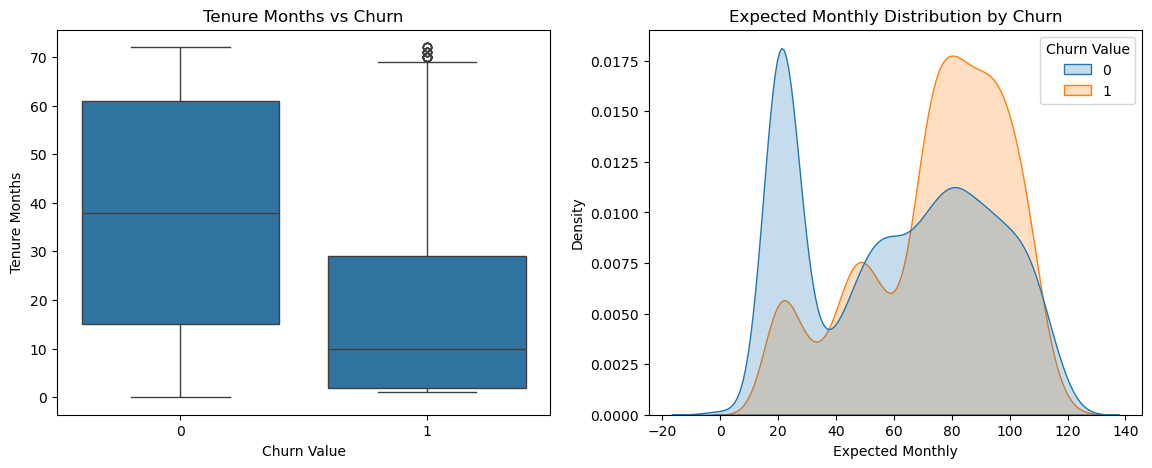

In [48]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="Churn Value", y="Tenure Months", ax=ax1)
ax1.set_title("Tenure Months vs Churn")

sns.kdeplot(data=df, x="Expected Monthly", hue="Churn Value", fill=True, ax=ax2, common_norm=False)
ax2.set_title("Expected Monthly Distribution by Churn")

plt.show()

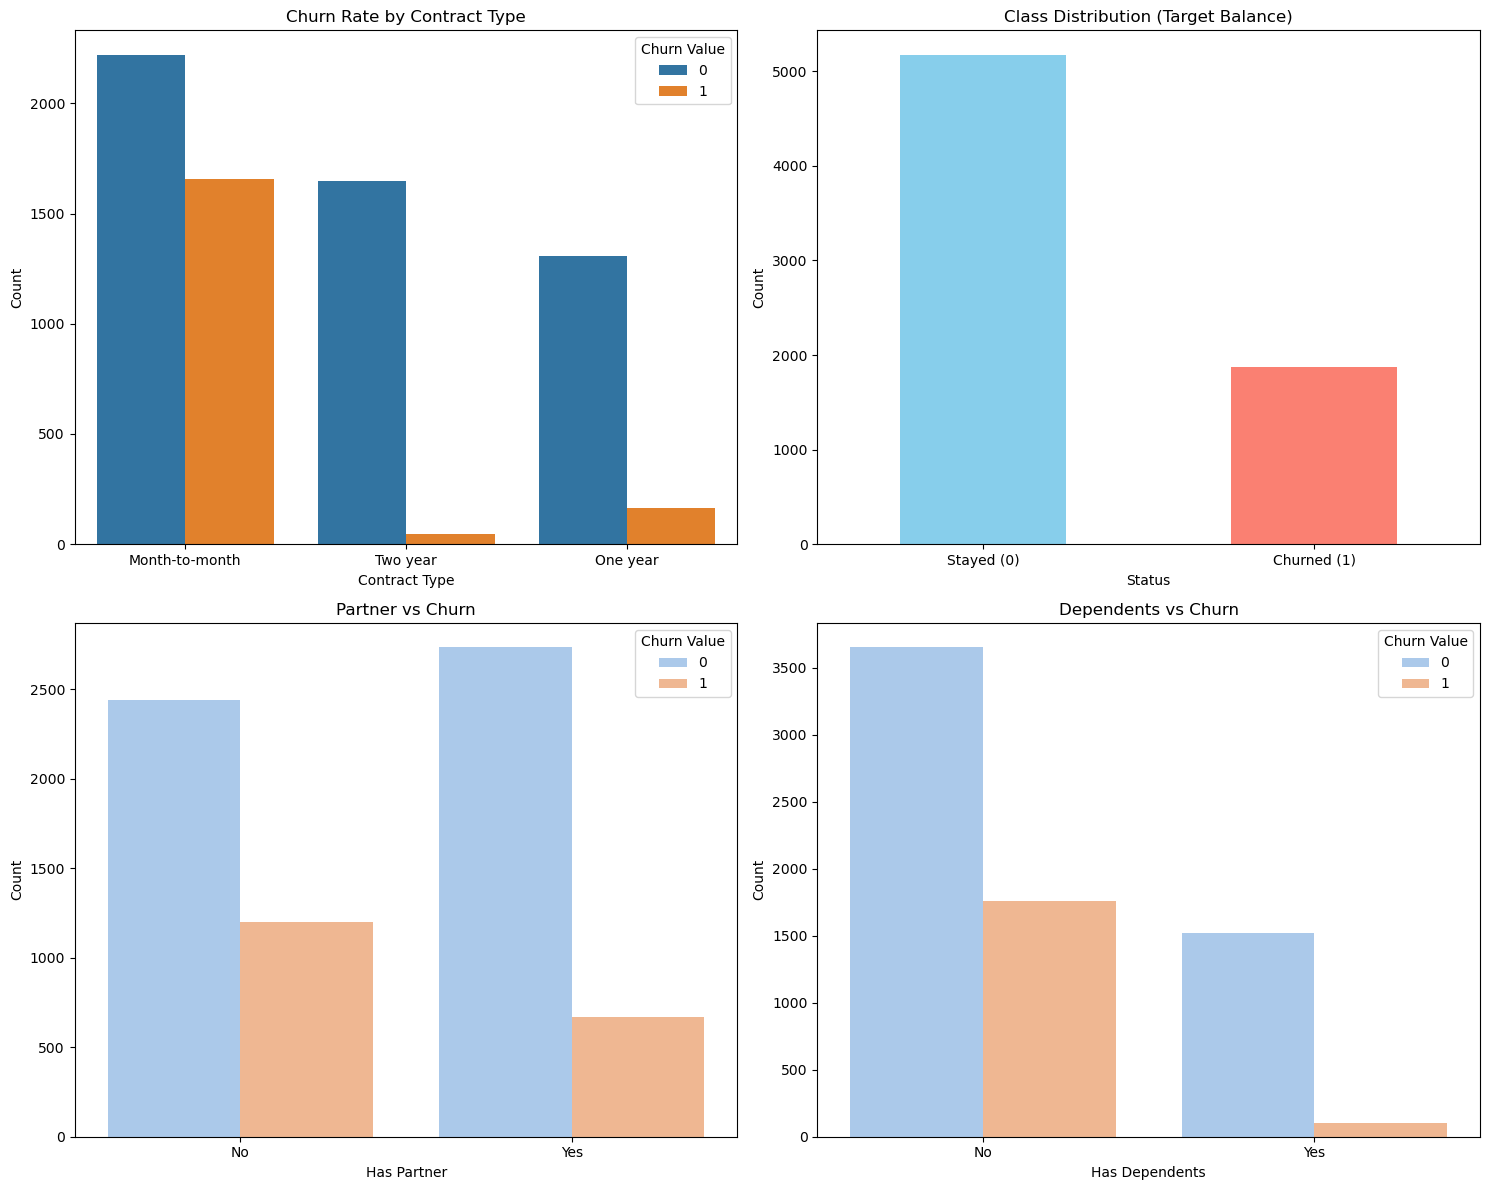

In [49]:
x = df.groupby(["Dependents", "Churn Value"]).size()
xfig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 12))

ax1, ax2, ax3, ax4 = axes.flatten()

sns.countplot(data=df, x="Contract", hue="Churn Value", ax=ax1)
ax1.set_title("Churn Rate by Contract Type", fontsize=12)
ax1.set_xlabel("Contract Type")
ax1.set_ylabel("Count")

df["Churn Value"].value_counts().plot(kind="bar", color=["skyblue", "salmon"], ax=ax2)
ax2.set_title("Class Distribution (Target Balance)", fontsize=12)
ax2.set_xlabel("Status")
ax2.set_ylabel("Count")
ax2.set_xticks([0, 1])
ax2.set_xticklabels(["Stayed (0)", "Churned (1)"], rotation=0)

sns.countplot(data=df, x="Partner", hue="Churn Value", palette="pastel", ax=ax3)
ax3.set_title("Partner vs Churn", fontsize=12)
ax3.set_xlabel("Has Partner")
ax3.set_ylabel("Count")

sns.countplot(data=df, x="Dependents", hue="Churn Value", palette="pastel", ax=ax4)
ax4.set_title("Dependents vs Churn", fontsize=12)
ax4.set_xlabel("Has Dependents")
ax4.set_ylabel("Count")

plt.tight_layout()
plt.show()

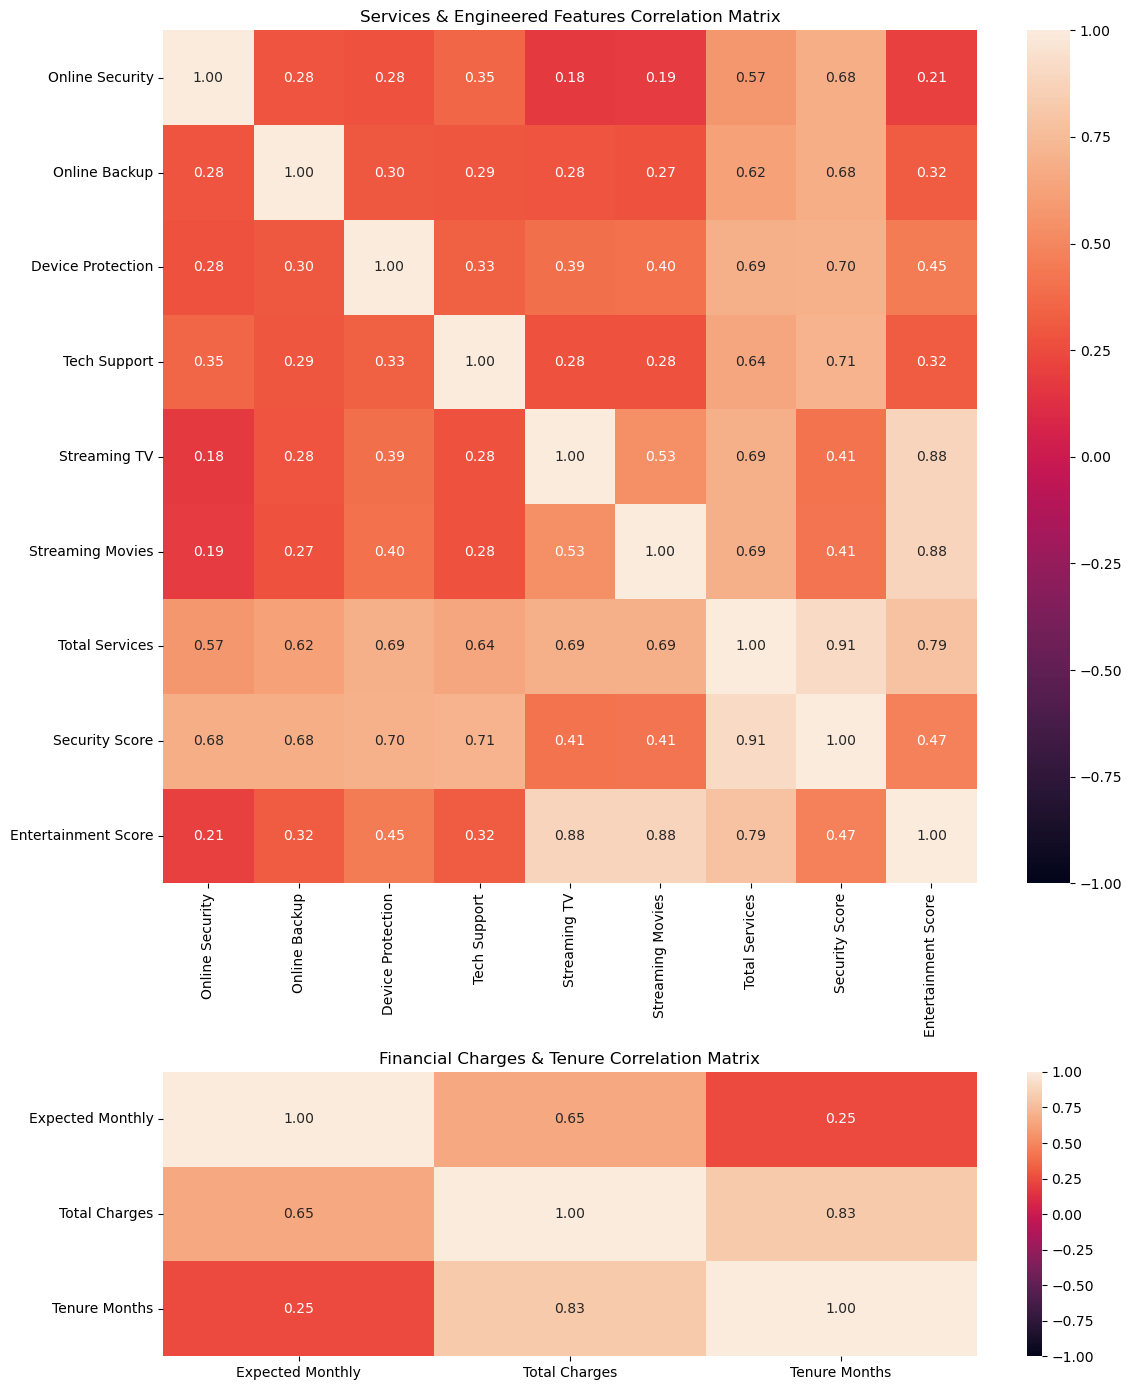

In [50]:
columns = ["Online Security", "Online Backup", "Device Protection", "Tech Support", "Streaming TV", "Streaming Movies"]
new_cols = ["Total Services", "Security Score", "Entertainment Score"]

df_numeric = df[columns].map(lambda x: 1 if x == "Yes" else 0)
df_analysis = df_numeric.join(df[new_cols])
corr1 = df_analysis.corr()

chrge_cols = ["Expected Monthly", "Total Charges", "Tenure Months"]
corr2 = df[chrge_cols].corr()

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 14), gridspec_kw={'height_ratios': [3, 1]})

sns.heatmap(corr1, annot=True, fmt=".2f", vmin=-1, vmax=1, ax=ax1)
ax1.set_title("Services & Engineered Features Correlation Matrix")

sns.heatmap(corr2, annot=True, fmt=".2f", vmin=-1, vmax=1, ax=ax2)
ax2.set_title("Financial Charges & Tenure Correlation Matrix")

plt.tight_layout()
plt.show()

### Feature Selection Summary

- **Removed `Total Services`:** Dropped due to high correlation (**0.91**) with `Security Score` to prevent multicollinearity.
- **Removed `Entertainment Score`:** Dropped due to high correlation (**0.87**) with original streaming features. Our tree-based models (`RandomForest`, `GradientBoosting`) can natively handle these interactions from the raw categorical inputs.
- **Retained Financial Features:** `Expected Monthly` was kept as it provides a clean financial signal with very low correlation (**0.25**) to `Tenure Months`. The **0.83** correlation between `Total Charges` and `Tenure Months` is naturally managed by tree algorithms.

**Conclusion:** The dataset is optimized and ready for the modeling pipeline (`src/train.py`) without risks of collinearity or data leakage.